In [2]:
from misc import *
import constant

In [3]:
# upto 5 long track candidates isMuon
LTRACK5_HIGH_MASS_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/LeadLead_dimuon_HighMass_all.root"
DEFAULT_TREE_NAME = "dimuonTuple/DecayTree"

no_ismuon_df = load_root(LTRACK5_HIGH_MASS_FILE_PATH, DEFAULT_TREE_NAME)
df = no_ismuon_df[(no_ismuon_df["muplus_isMuon"] == True) & (no_ismuon_df["muminus_isMuon"] == True)]

In [4]:
def add_upsilon(ax, xS):
    for i in xS:
        mass = eval(f"constant.UPSILON_{i}S_MASS")
        label = r"$M(\Upsilon\mathrm{(" + f"{i}" + r"S)})$"
        ax.axvline(mass, color="k", linewidth=1.5, label=label, ls="--")

# Upsilon Cuts


## isMuon, nLongTracks


Histogram not saved to file


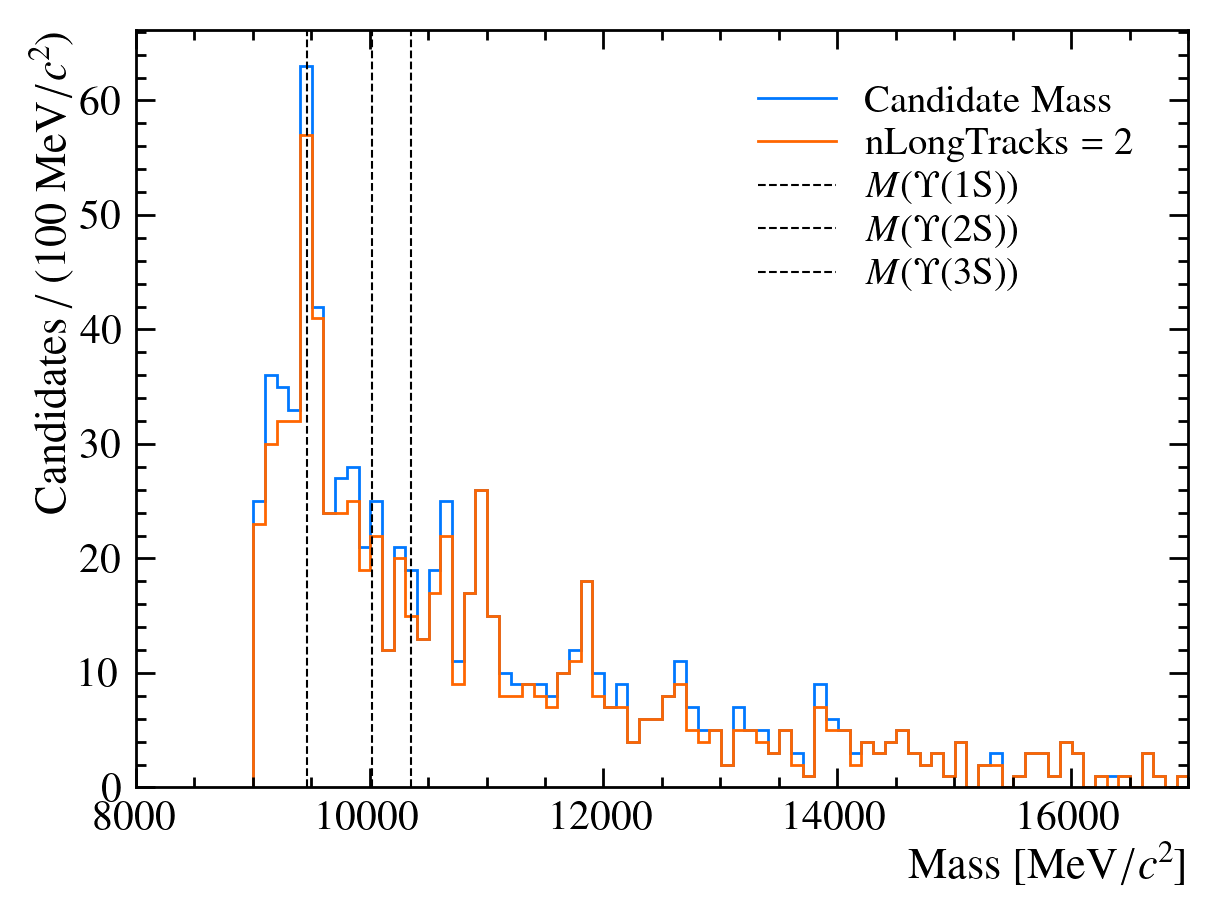

In [26]:
twoLongTracks_df = df[df["nLongTracks"] == 2]
fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"], "Candidate Mass", bins=100),
     HistogramPlot(twoLongTracks_df["J_psi_1S_M"], "nLongTracks = 2", bins=100)],
    False,
    xlim=[8000, 17_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,4))
ax.legend()

Histogram not saved to file


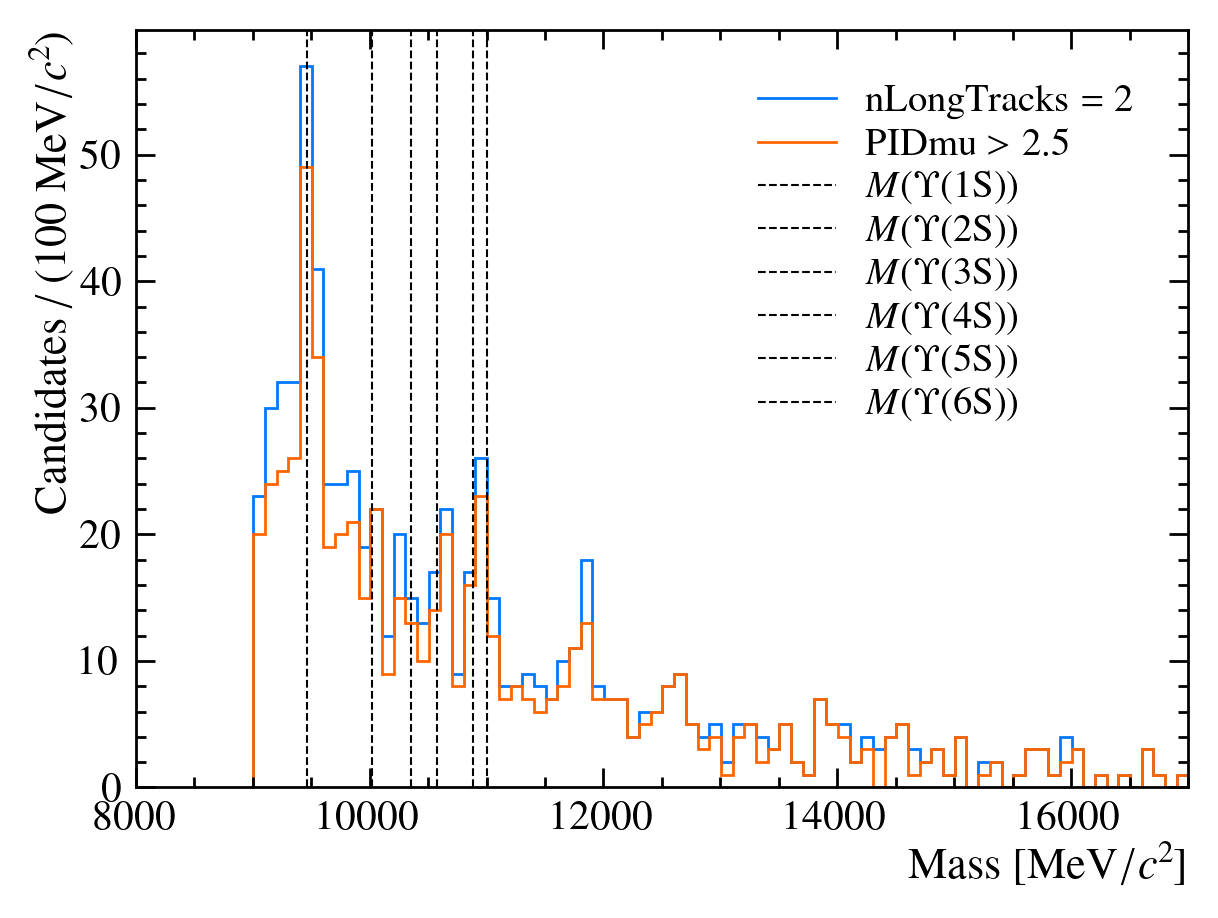

In [6]:
pidmu_df = twoLongTracks_df[
    (twoLongTracks_df["muplus_PIDmu"] >= 2.5)
    & (twoLongTracks_df["muminus_PIDmu"] >= 2.5)
]

fig, ax = histogram_fig(
    [
        HistogramPlot(twoLongTracks_df["J_psi_1S_M"], "nLongTracks = 2", bins=100),
        HistogramPlot(pidmu_df["J_psi_1S_M"], "PIDmu $>2.5$", bins=100),
    ],
    False,
    xlim=[8000, 17_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass",
)
add_upsilon(ax, range(1, 7))
ax.legend()

Histogram not saved to file


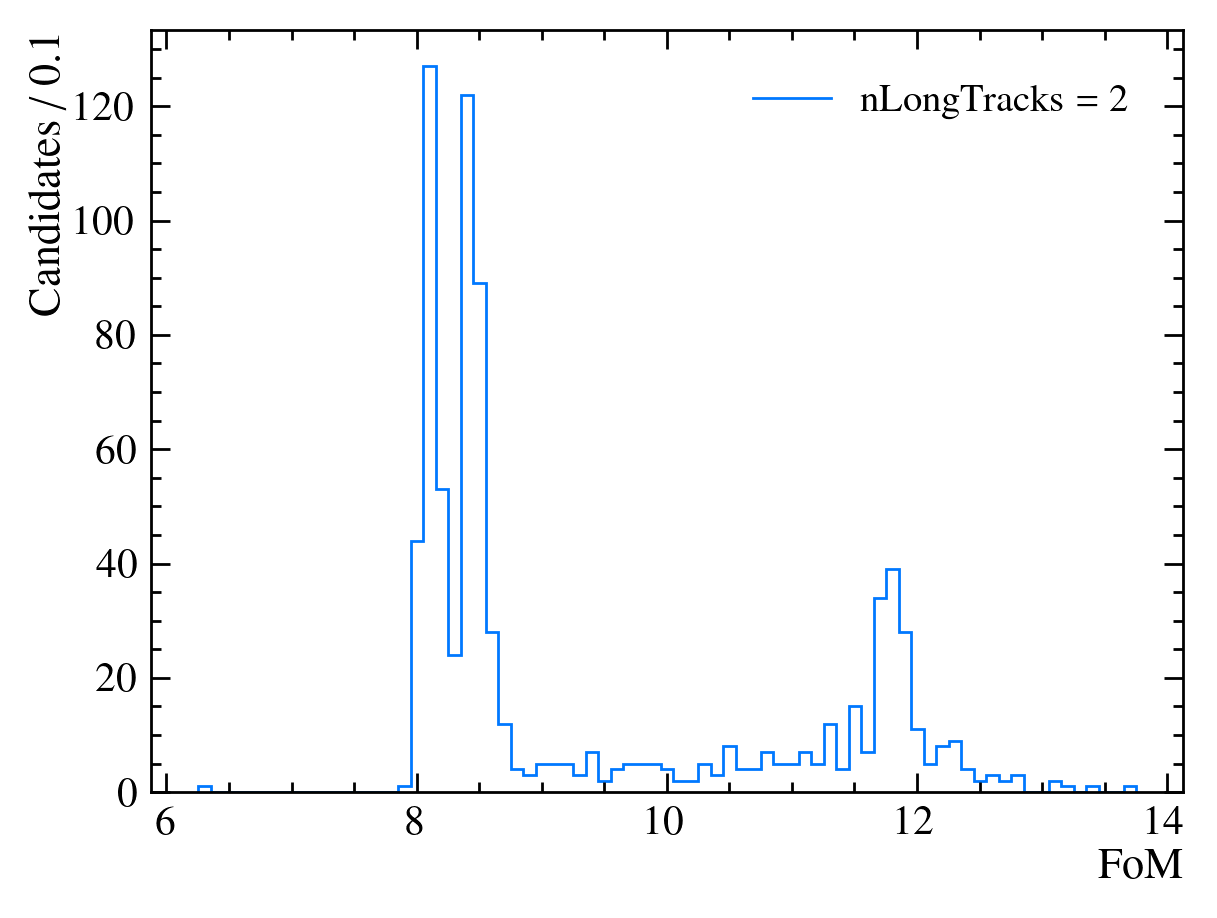

In [7]:
fig, ax = histogram_fig(
    [
        HistogramPlot(twoLongTracks_df["log_hrc_fom"], "nLongTracks = 2", bins=0.1),
    ],
    False,
    xlabel="FoM",
)

Histogram not saved to file


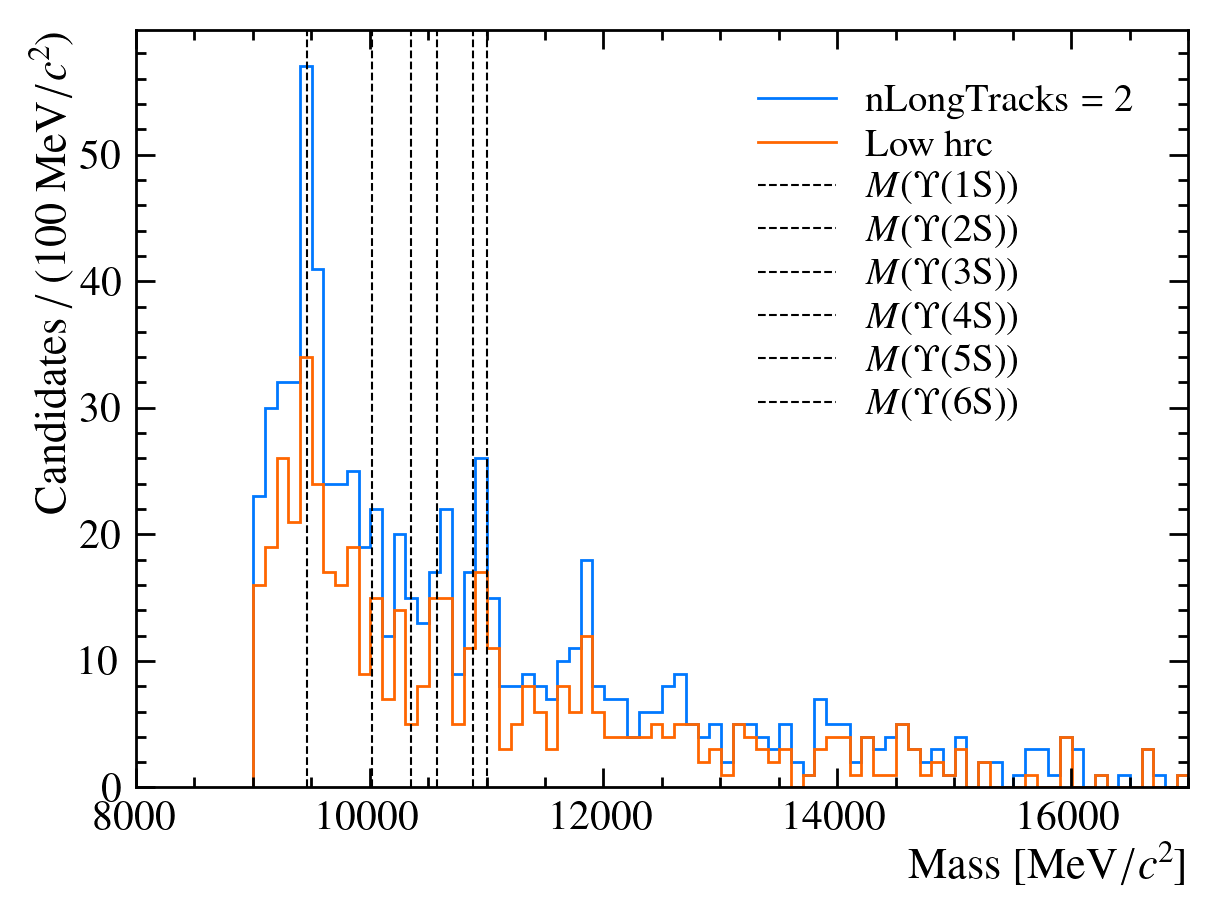

In [8]:
low_hrc_df = twoLongTracks_df[twoLongTracks_df["log_hrc_fom"] < 9]

fig, ax = histogram_fig(
    [HistogramPlot(twoLongTracks_df["J_psi_1S_M"], "nLongTracks = 2", bins=100),
     HistogramPlot(low_hrc_df["J_psi_1S_M"], "Low hrc", bins=100)],
    False,
    xlim=[8000, 17_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,7))
ax.legend()

Histogram not saved to file


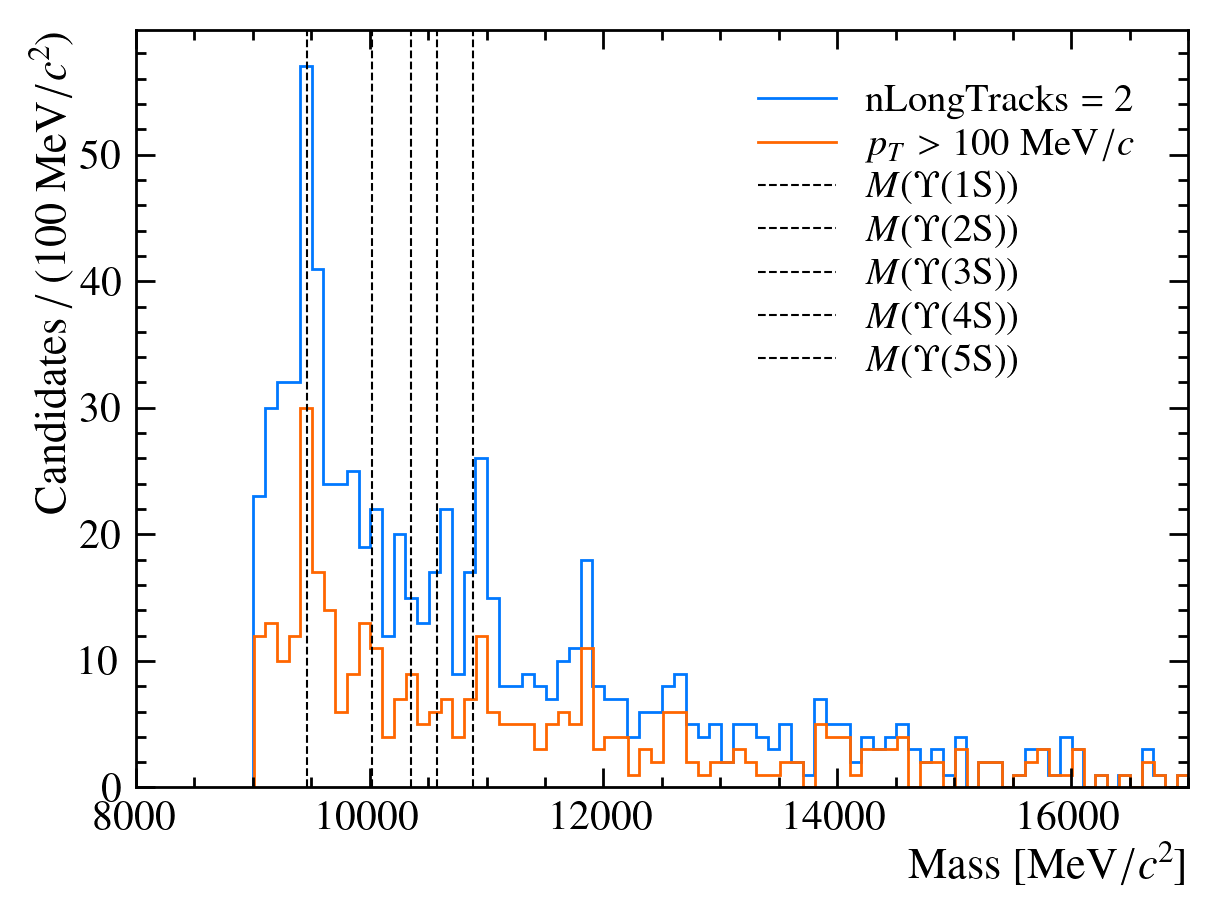

In [9]:
high_pt_df = twoLongTracks_df[twoLongTracks_df["J_psi_1S_PT"] > 100]

fig, ax = histogram_fig(
    [HistogramPlot(twoLongTracks_df["J_psi_1S_M"], "nLongTracks = 2", bins=100),
     HistogramPlot(high_pt_df["J_psi_1S_M"], r"$p_T > 100 \ \mathrm{MeV}/c$", bins=100)],
    False,
    xlim=[8000, 17_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,6))
ax.legend()

## Attempting cuts from Measurement of Υ production in pp collisions at √s = 7 TeV
https://link.springer.com/article/10.1140/epjc/s10052-012-2025-y

/software/ai21208/Code/misc.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Histogram not saved to file


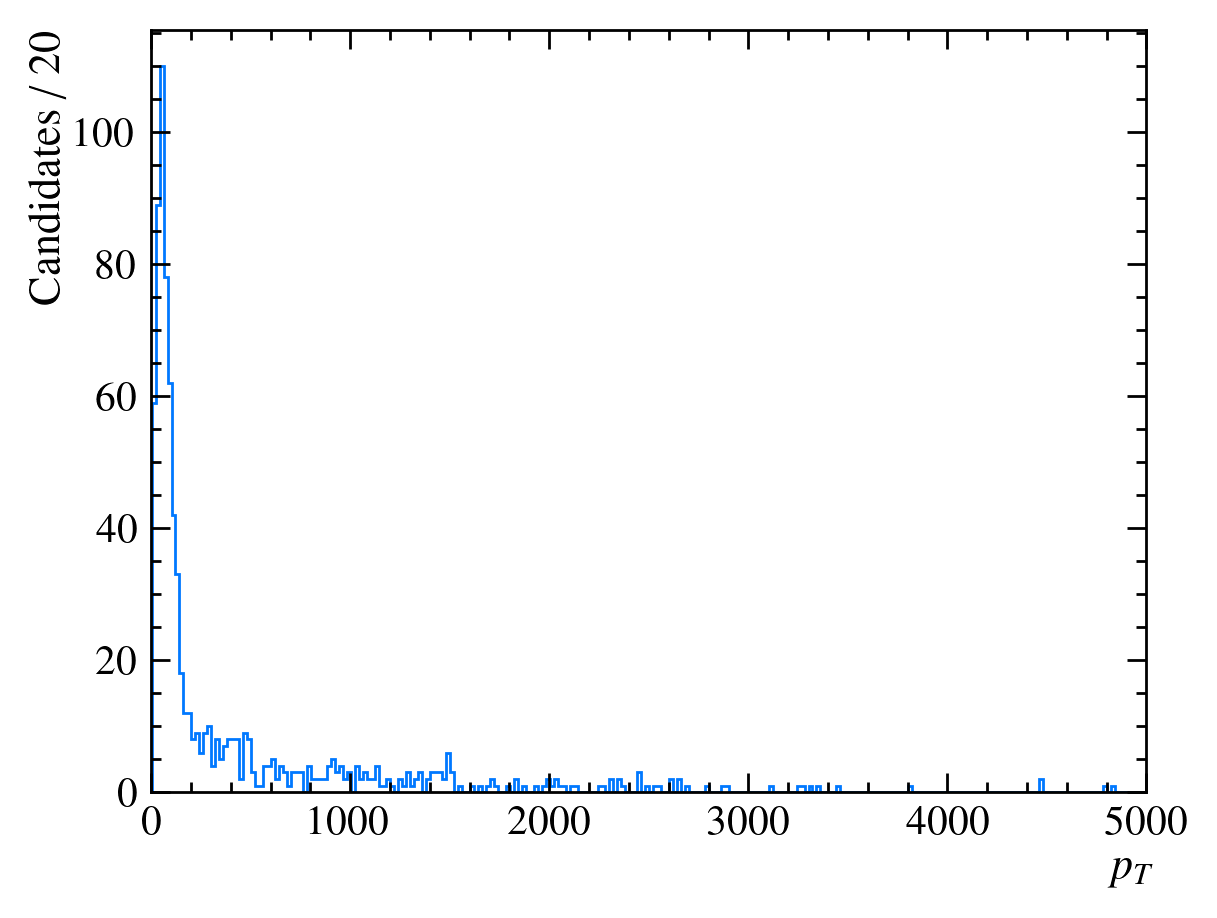

In [10]:
fig, ax = histogram_fig(
    [
        HistogramPlot(twoLongTracks_df["J_psi_1S_PT"], "", bins=20),
    ],
    False,
    xlabel="$p_T$",
    xlim=[0, 5000]
)

/software/ai21208/Code/misc.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/software/ai21208/Code/misc.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Histogram not saved to file
Histogram not saved to file


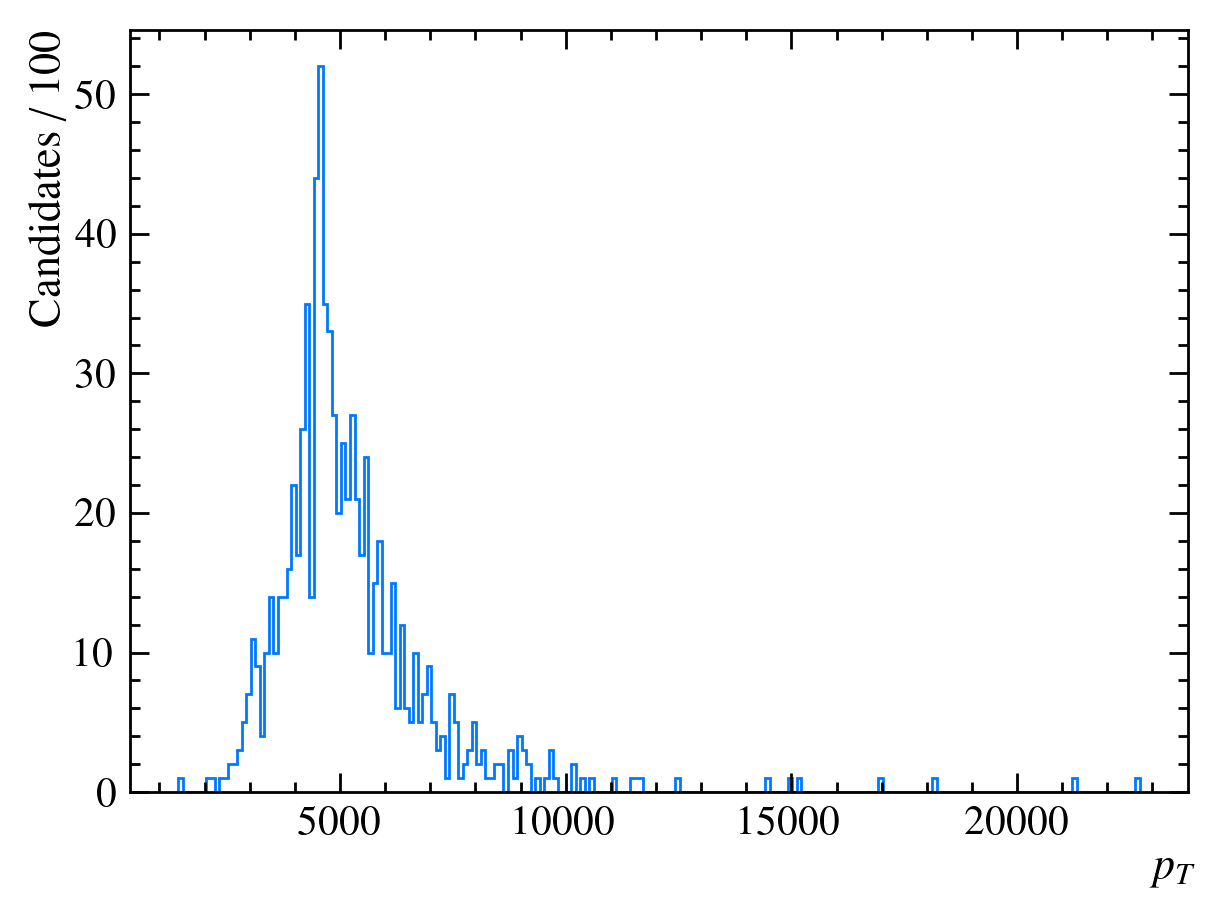

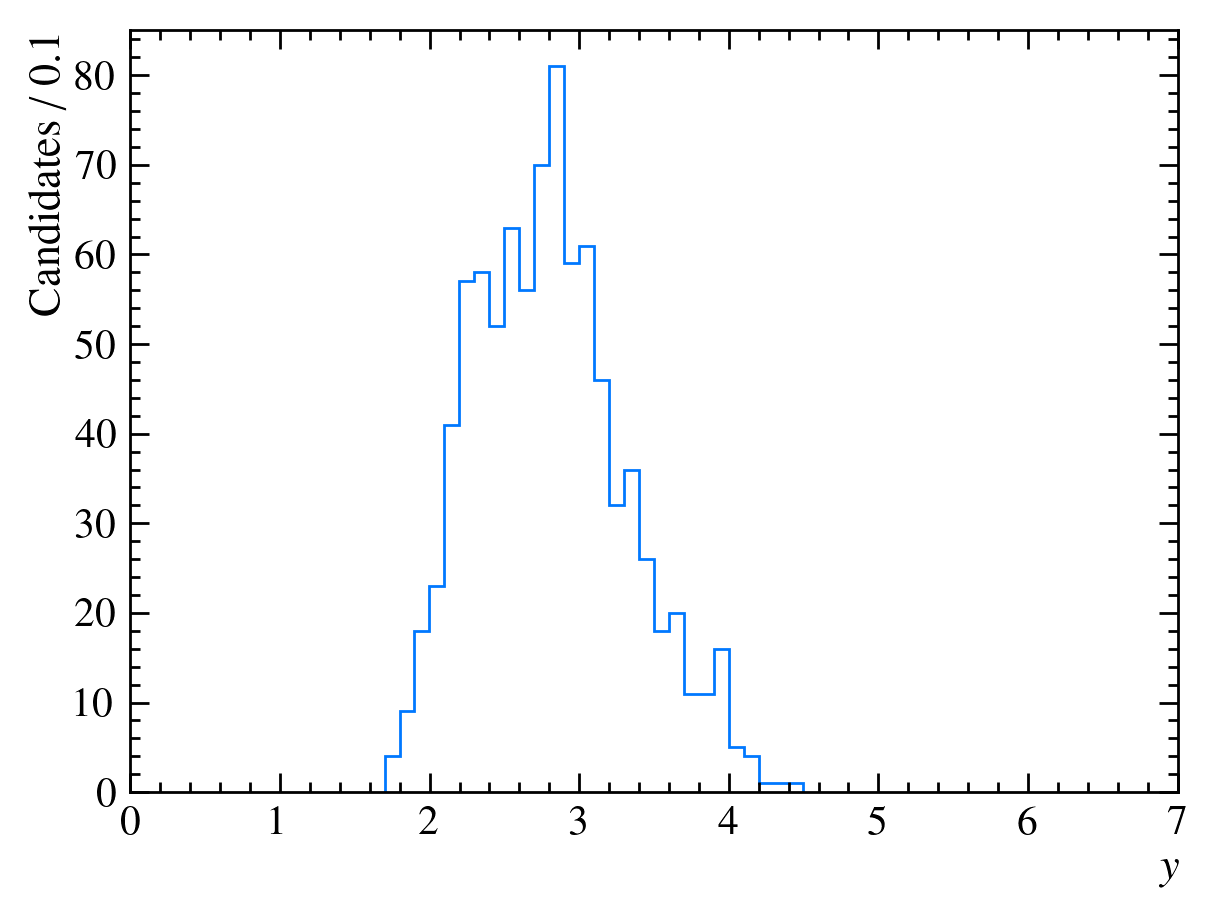

In [11]:
fig, ax = histogram_fig(
    [
        HistogramPlot(twoLongTracks_df["muplus_PT"], "", bins=100),
    ],
    False,
    xlabel="$p_T$",
    # xlim=[0,]
)

fig, ax = histogram_fig(
    [
        HistogramPlot(df["J_psi_1S_Y"], "", bins=0.1),
    ],
    False,
    xlabel="$y$",
    xlim=[0,7]
)

In [12]:
# low_pt_df = twoLongTracks_df[twoLongTracks_df["J_psi_1S_PT"] < 100]

# fig, ax = histogram_fig(
#     [HistogramPlot(twoLongTracks_df["J_psi_1S_M"], "nLongTracks = 2", bins=50),
#      HistogramPlot(low_pt_df["J_psi_1S_M"], r"$p_T > 100 \ \mathrm{MeV}/c$", bins=50)],
#     False,
#     xlim=[8000, 12_000],
#     unit_tex=r"\mathrm{MeV}/c^2",
#     xlabel="Mass"
# )
# add_upsilon(ax, range(1,6))
# ax.legend()

/software/ai21208/Code/misc.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Histogram not saved to file


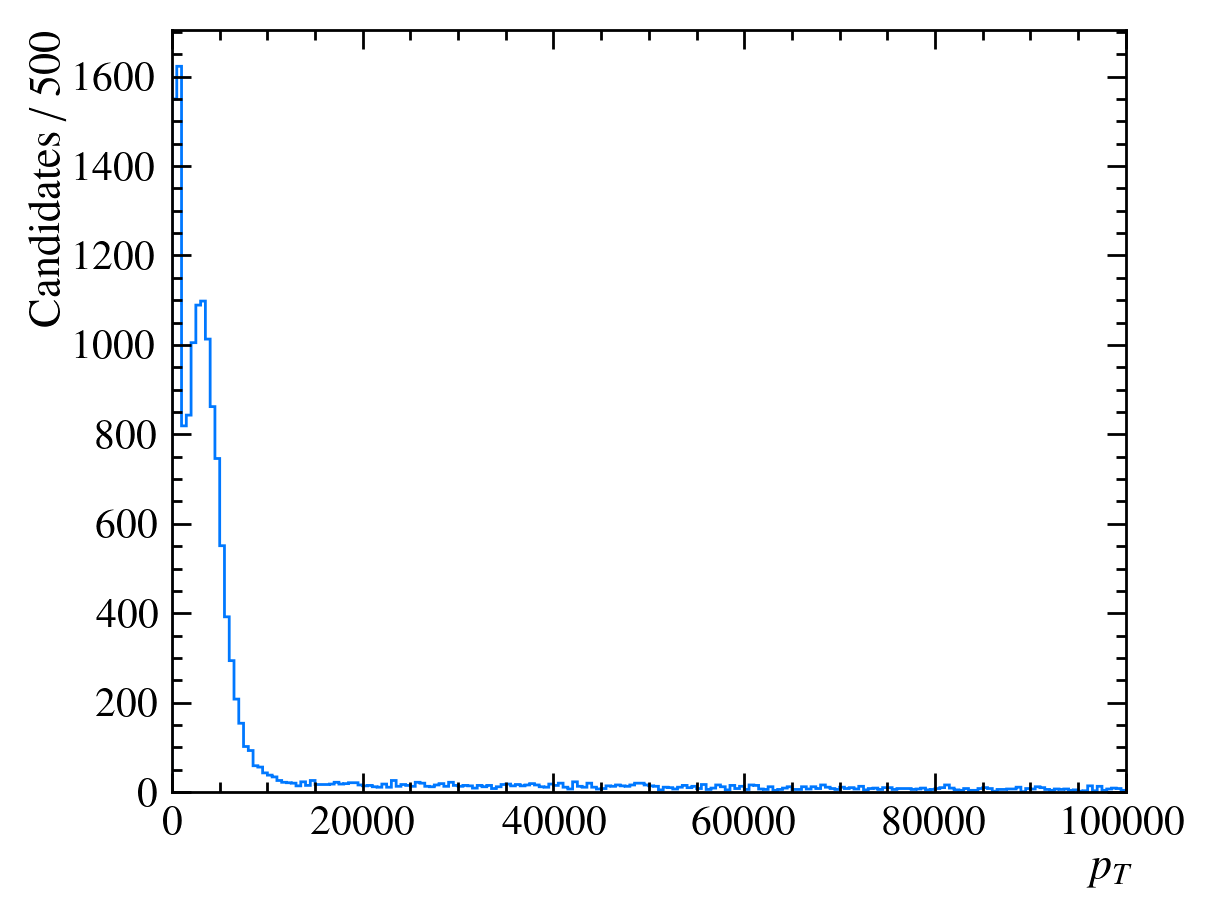

In [13]:
fig, ax = histogram_fig(
    [
        HistogramPlot(no_ismuon_df["muplus_PT"].astype("float64"), "", bins=500),
    ],
    False,
    xlabel="$p_T$",
    xlim=[0,1e5]
)



### $p_T(\mu^{\pm}) > 1 \mathrm{GeV}/c$

15165
16506
Histogram not saved to file


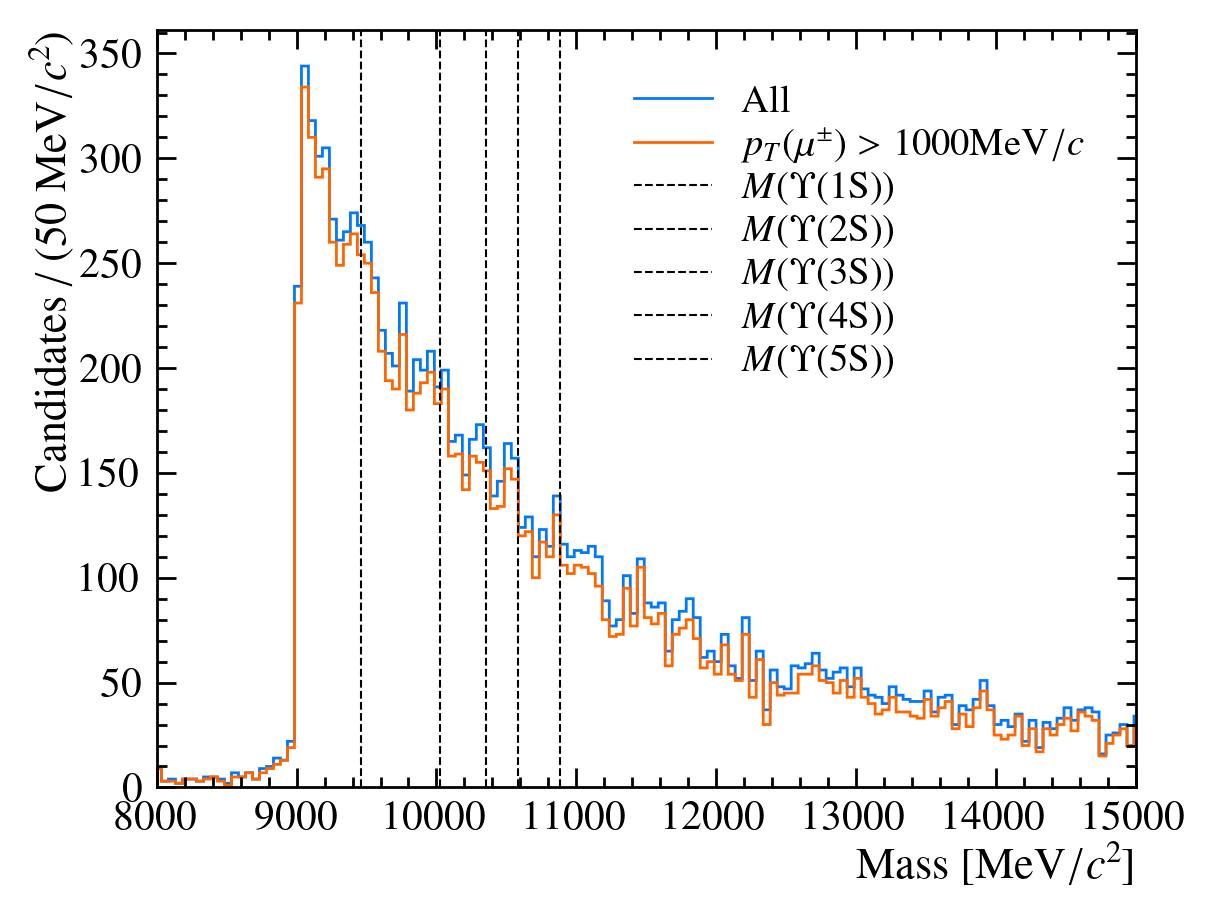

In [14]:
high_pt_muon_df = no_ismuon_df[(no_ismuon_df["muplus_PT"] > 300) & (no_ismuon_df["muminus_PT"] > 300)]

print(len(high_pt_muon_df))
print(len(no_ismuon_df))

fig, ax = histogram_fig(
    [HistogramPlot(no_ismuon_df["J_psi_1S_M"], "All", bins=50),
     HistogramPlot(high_pt_muon_df["J_psi_1S_M"], r"$p_T(\mu^\pm) > 1000 \mathrm{MeV}/c$", bins=50)],
    False,
    xlim=[8000, 15_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,6))
ax.legend()

### $p_T(\Upsilon) < 15 \mathrm{GeV}/c$

15165
9222
Histogram not saved to file


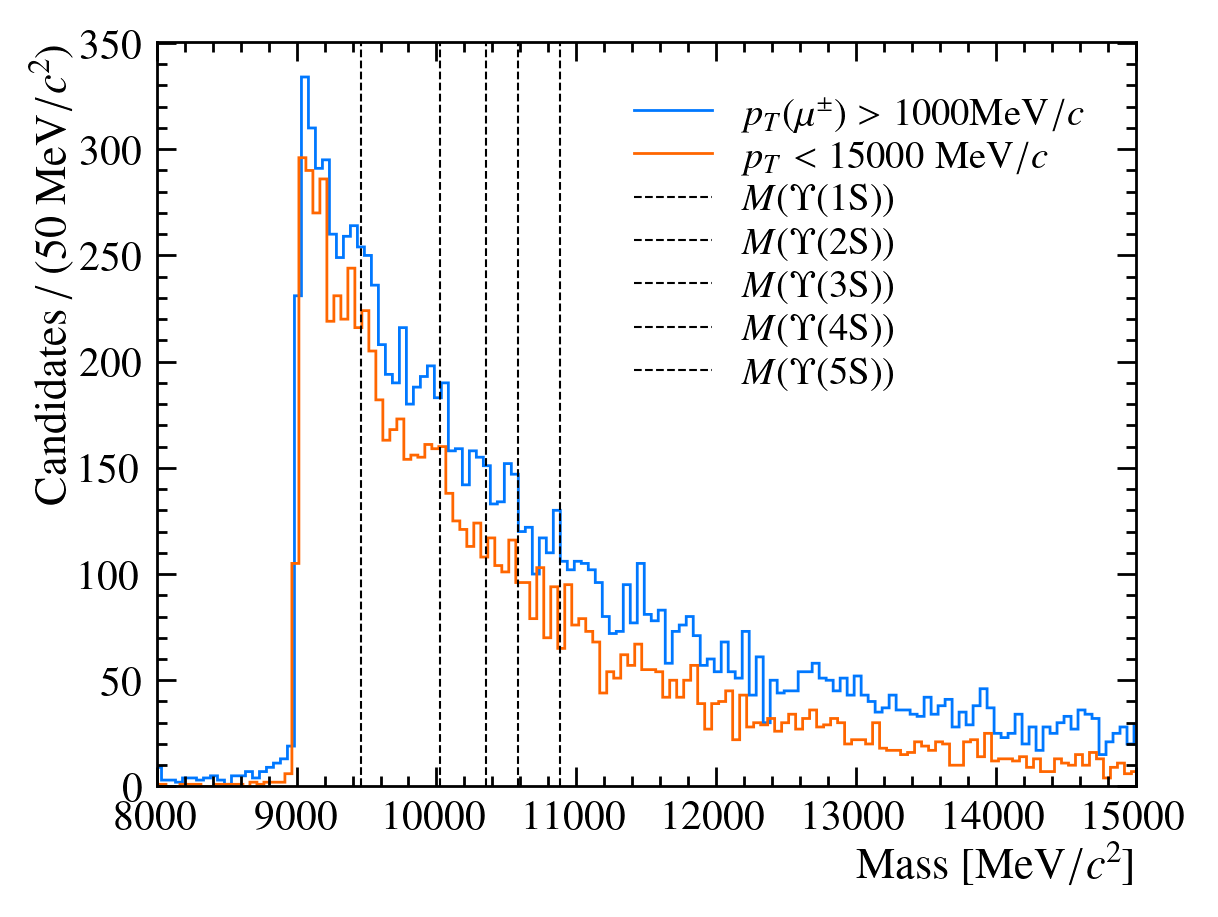

In [15]:
pt_cut_df = high_pt_muon_df[high_pt_muon_df["J_psi_1S_PT"] < 15_000]

print(len(high_pt_muon_df))
print(len(pt_cut_df))

fig, ax = histogram_fig(
    [HistogramPlot(high_pt_muon_df["J_psi_1S_M"], r"$p_T(\mu^\pm) > 1000 \mathrm{MeV}/c$", bins=50),
     HistogramPlot(pt_cut_df["J_psi_1S_M"], r"$p_T < 15000 \ \mathrm{MeV}/c$", bins=50)],
    False,
    xlim=[8000, 15_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,6))
ax.legend()

#### $\mu^{\pm} Fit qualities$

/software/ai21208/Code/misc.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Histogram not saved to file


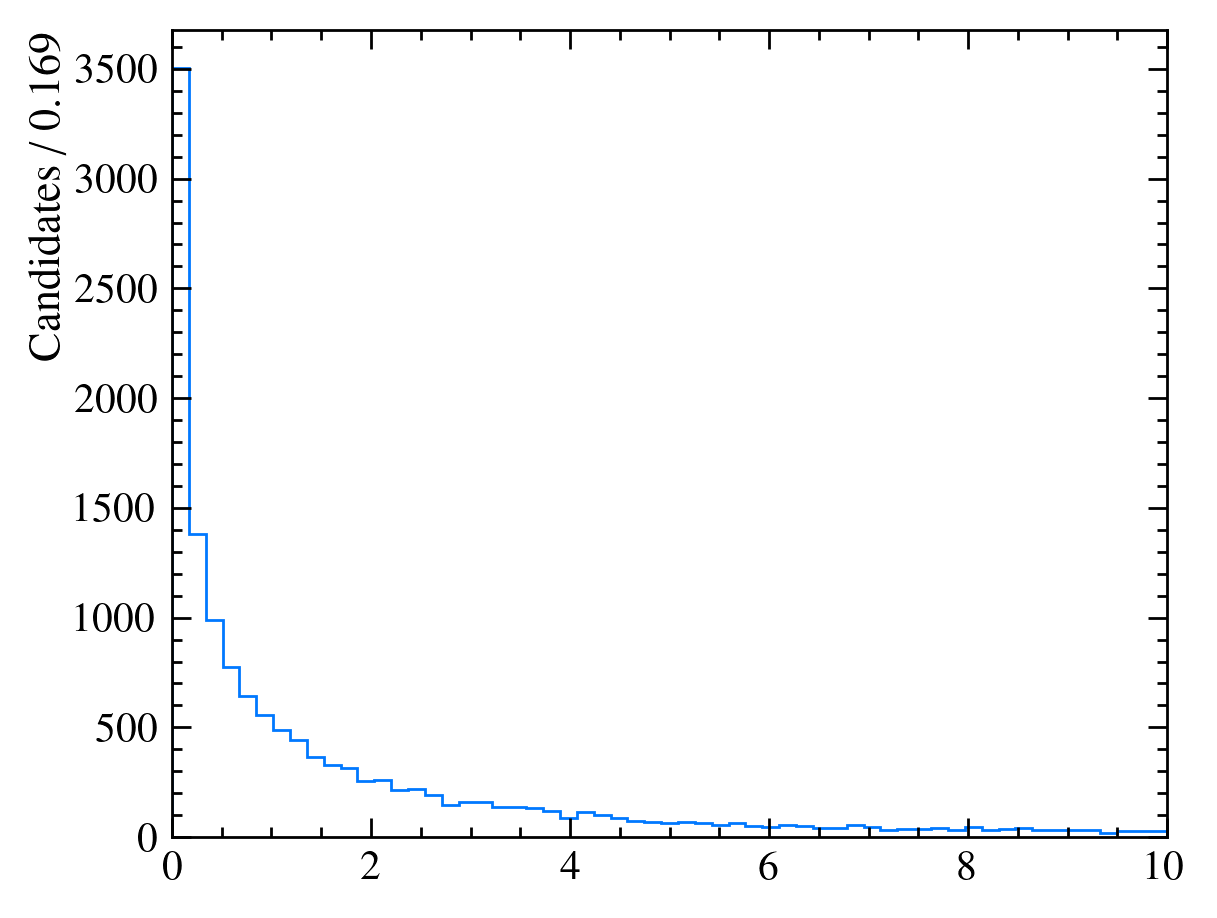

In [16]:
fig, ax = histogram_fig(
    [
        HistogramPlot(no_ismuon_df["J_psi_1S_ENDVERTEX_CHI2"][no_ismuon_df["J_psi_1S_ENDVERTEX_CHI2"] < 10].astype("float64"), ""),
    ],
    False,
    # xlabel="$p_T$",
    xlim=[0,10]
)

9222
8018
Histogram not saved to file


<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_351311/3348792553.py:8: SyntaxWarning: invalid escape sequence '\m'
  HistogramPlot(good_track_fit_df["J_psi_1S_M"], "$\mu^\pm$ track $\chi^2 < 2$", bins=50)],


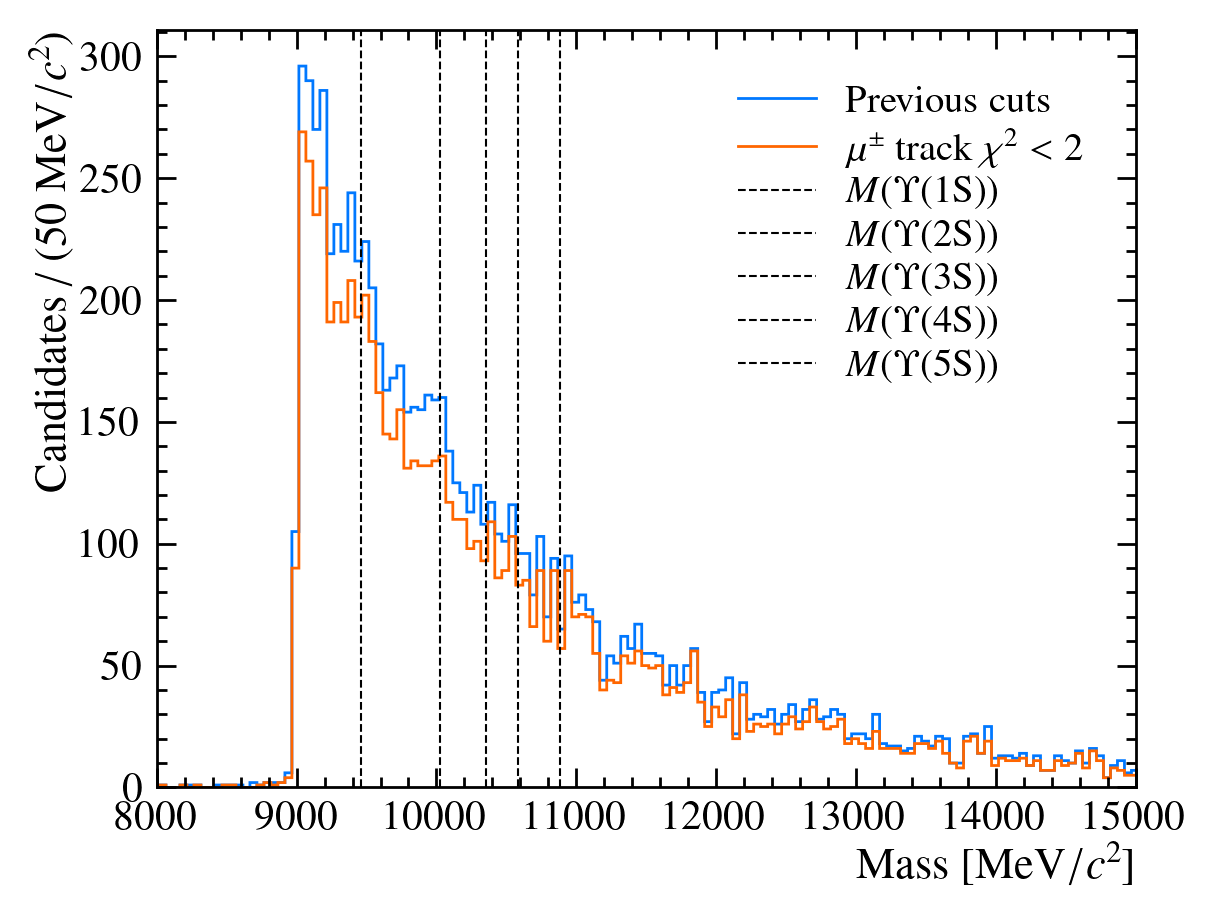

In [17]:
good_track_fit_df = pt_cut_df[(pt_cut_df["muplus_TRACK_CHI2NDOF"] < 2) & (pt_cut_df["muminus_TRACK_CHI2NDOF"] < 2)]

print(len(pt_cut_df))
print(len(good_track_fit_df))

fig, ax = histogram_fig(
    [HistogramPlot(pt_cut_df["J_psi_1S_M"], "Previous cuts", bins=50),
     HistogramPlot(good_track_fit_df["J_psi_1S_M"], "$\mu^\pm$ track $\chi^2 < 2$", bins=50)],
    False,
    xlim=[8000, 15_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,6))
ax.legend()

8018
5903
Histogram not saved to file


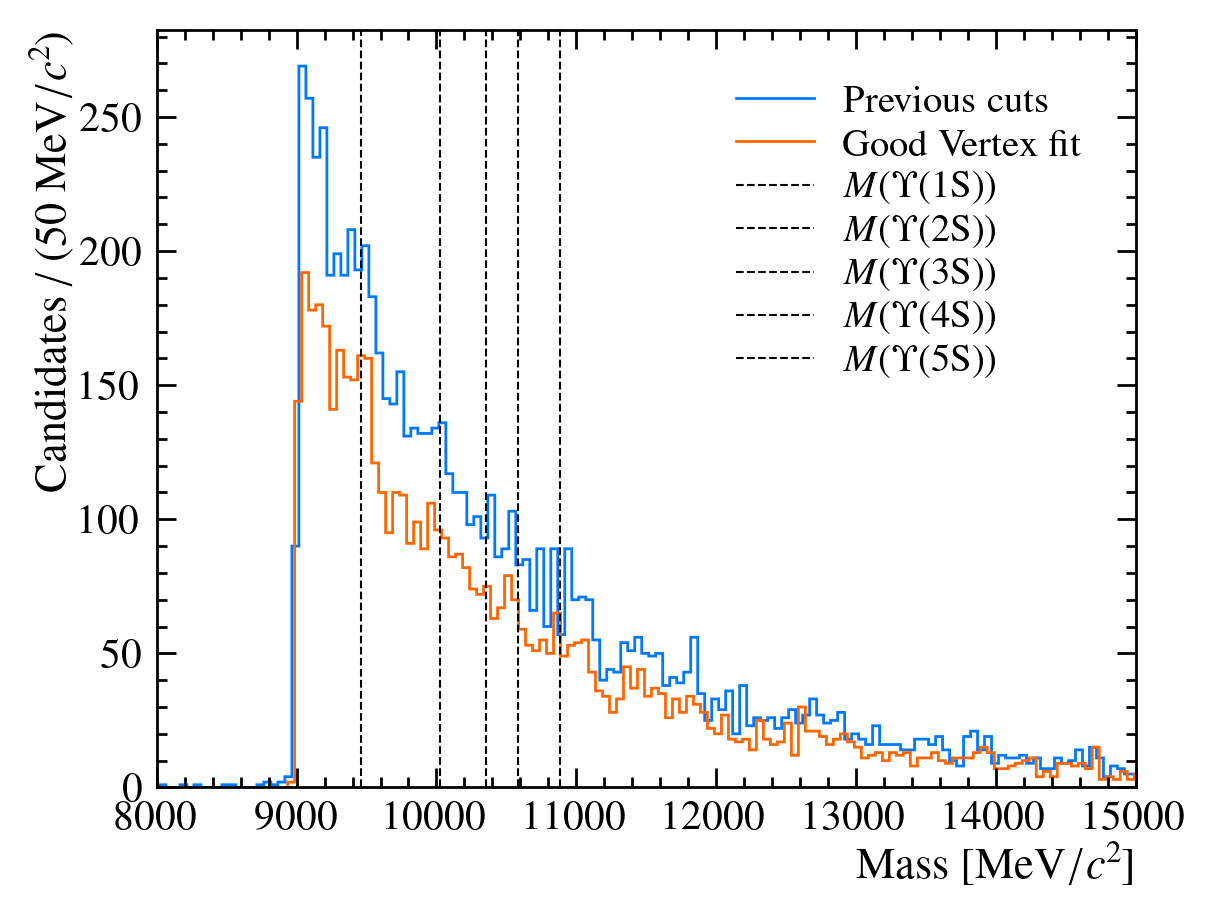

In [18]:
good_vertex_fit_df = good_track_fit_df[(good_track_fit_df["J_psi_1S_ENDVERTEX_CHI2"] < 2)]

print(len(good_track_fit_df))
print(len(good_vertex_fit_df))

fig, ax = histogram_fig(
    [HistogramPlot(good_track_fit_df["J_psi_1S_M"], "Previous cuts", bins=50),
     HistogramPlot(good_vertex_fit_df["J_psi_1S_M"], "Good Vertex fit", bins=50)],
    False,
    xlim=[8000, 15_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,6))
ax.legend()

##### isMuon

5903
662
Histogram not saved to file


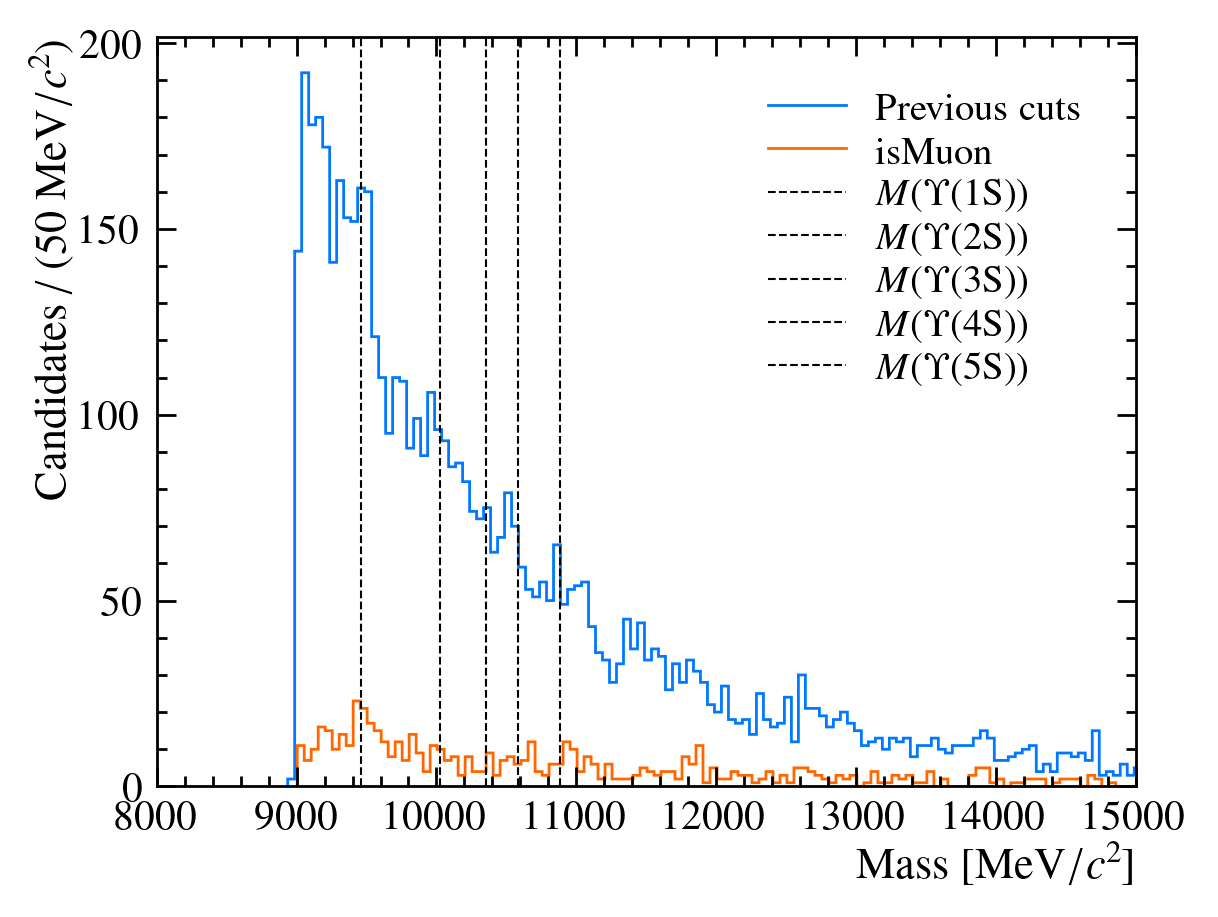

In [19]:
final_ismuon_df = good_vertex_fit_df[(good_vertex_fit_df["muplus_isMuon"] == True) & (good_vertex_fit_df["muminus_isMuon"] == True)]

print(len(good_vertex_fit_df))
print(len(final_ismuon_df))

fig, ax = histogram_fig(
    [HistogramPlot(good_vertex_fit_df["J_psi_1S_M"], "Previous cuts", bins=50),
     HistogramPlot(final_ismuon_df["J_psi_1S_M"], "isMuon", bins=50)],
    False,
    xlim=[8000, 15_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,6))
ax.legend()

##### PIDmu

5903
829
Histogram not saved to file
Histogram not saved to file


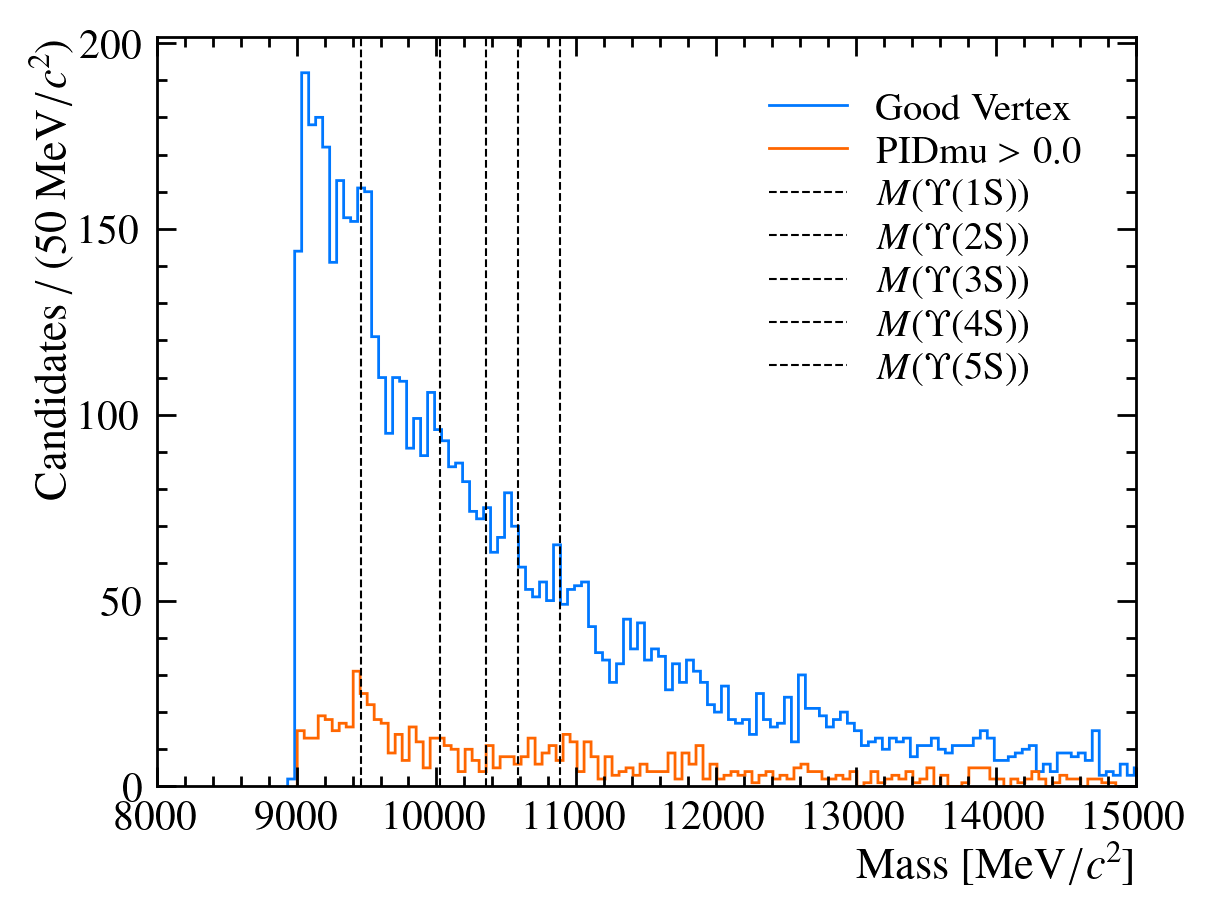

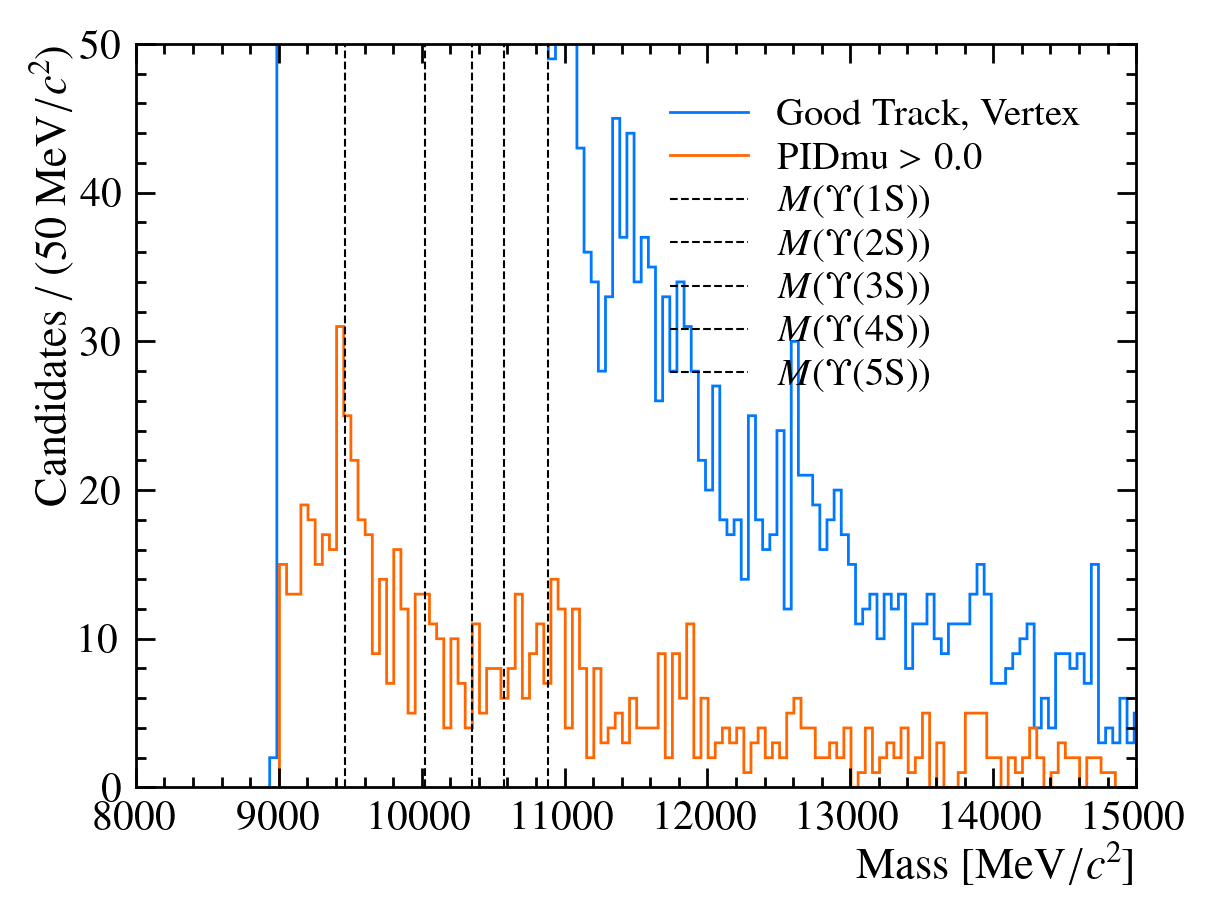

In [20]:
pidmu_noismuon_df = good_vertex_fit_df[(good_vertex_fit_df["muplus_PIDmu"] > 0.0) & (good_vertex_fit_df["muminus_PIDmu"]  > 0.0)]

print(len(good_vertex_fit_df))
print(len(pidmu_noismuon_df))

fig, ax = histogram_fig(
    [HistogramPlot(good_vertex_fit_df["J_psi_1S_M"], "Good Vertex", bins=50),
     HistogramPlot(pidmu_noismuon_df["J_psi_1S_M"], "PIDmu $> 0.0$", bins=50)],
    False,
    xlim=[8000, 15_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,6))
ax.legend()

fig, ax = histogram_fig(
    [HistogramPlot(good_vertex_fit_df["J_psi_1S_M"], "Good Track, Vertex", bins=50),
     HistogramPlot(pidmu_noismuon_df["J_psi_1S_M"], "PIDmu $> 0.0$", bins=50)],
    False,
    xlim=[8000, 15_000],
    ylim=[0,50],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,6))
ax.legend()

# Upsilon Fitting
## Creating a model

In [21]:
import zfit

/software/ai21208/Code/venv/lib/python3.12/site-packages/zfit/__init__.py:60: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(
2025-02-20 22:57:59.628456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740092279.652802  351311 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740092279.661352  351311 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [22]:
# obs
bounds = (9_200, 14_000)

# Define the observable (entire range of the data)
obs = zfit.Space("m", limits=bounds)

mu_1S = zfit.param.ConstantParameter("mu_1S", constant.UPSILON_1S_MASS)
mu_2S = zfit.param.ConstantParameter("mu_2S", constant.UPSILON_2S_MASS)
mu_3S = zfit.param.ConstantParameter("mu_3S", constant.UPSILON_3S_MASS)

sigma_at_1S = 53.9

sigma_1S = zfit.param.ConstantParameter("sigma_1S", sigma_at_1S)
sigma_2S = zfit.param.ConstantParameter(
    "sigma_2S", sigma_at_1S * constant.UPSILON_2S_MASS / constant.UPSILON_1S_MASS
)
sigma_3S = zfit.param.ConstantParameter(
    "sigma_3S", sigma_at_1S * constant.UPSILON_3S_MASS / constant.UPSILON_1S_MASS
)

Nsig_1S = zfit.Parameter("Nsig_1S", 50, 0)
Nsig_2S = zfit.Parameter("Nsig_2S", 20, 0)
Nsig_3S = zfit.Parameter("Nsig_3S", 10, 0)

# parameters for crystal ball
alpha_1S = zfit.Parameter("alpha_1S", 1)
alpha_2S = zfit.Parameter("alpha_2S", 1)
alpha_3S = zfit.Parameter("alpha_3S", 1)

n_1S = zfit.Parameter("n_1S", 2, 0.8)
n_2S = zfit.Parameter("n_2S", 2, 0.8)
n_3S = zfit.Parameter("n_3S", 2, 0.8)

# background
lambda_ = zfit.param.Parameter("lamba_", -0.0008)
Nbkg = zfit.param.Parameter("Nbkg", 400)


# model
signal_1S = zfit.pdf.CrystalBall(
    mu=mu_1S, sigma=sigma_1S, alpha=alpha_1S, n=n_1S, obs=obs
).create_extended(Nsig_1S)
signal_2S = zfit.pdf.Gauss(
    mu=mu_2S, sigma=sigma_2S, obs=obs
).create_extended(Nsig_2S)
signal_3S = zfit.pdf.Gauss(
    mu=mu_3S, sigma=sigma_3S, obs=obs
).create_extended(Nsig_3S)

background = zfit.pdf.Exponential(lam=lambda_, obs=obs).create_extended(Nbkg)


model = zfit.pdf.SumPDF([signal_1S, signal_2S, signal_3S, background])

2025-02-20 22:58:10.575287: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_SYSTEM_DRIVER_MISMATCH: system has unsupported display driver / cuda driver combination
2025-02-20 22:58:10.575464: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:262] kernel version 555.42.6 does not match DSO version 570.86.15 -- cannot find working devices in this configuration


## Plotting initial values

Histogram not saved to file


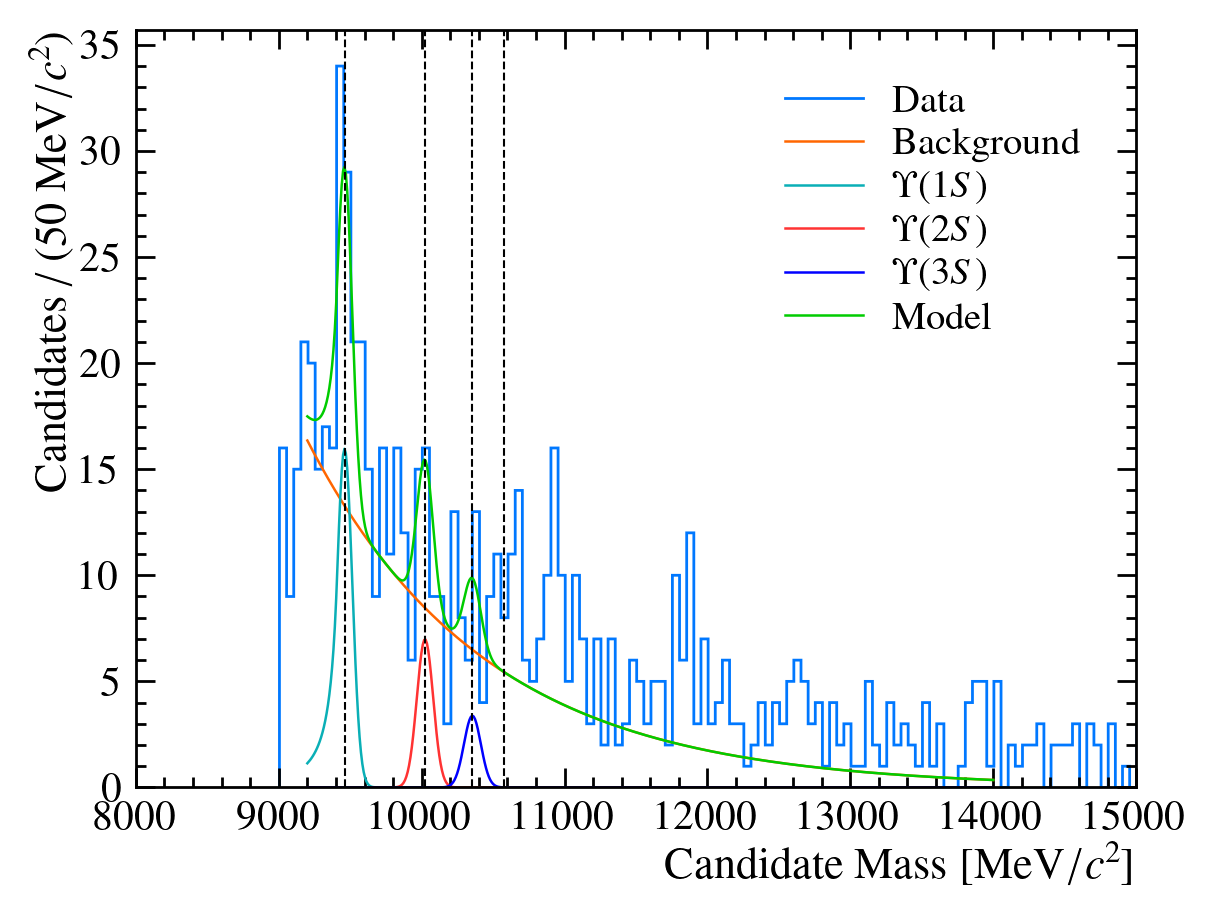

In [23]:
bin_width = 50
fig1, ax1 = histogram_fig(
    [p := HistogramPlot(df["J_psi_1S_M"], "Data", bins=bin_width)],
    False,
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Candidate Mass",
    xlim=[8000, 15_000],
)

x = np.linspace(*bounds, 500)
ax1.plot(x, background.ext_pdf(x)*bin_width, label="Background", linewidth=1.8)
ax1.plot(x, signal_1S.ext_pdf(x)*bin_width, label=r"$\Upsilon(1S)$", linewidth=1.8)
ax1.plot(x, signal_2S.ext_pdf(x)*bin_width, label=r"$\Upsilon(2S)$", linewidth=1.8)
ax1.plot(x, signal_3S.ext_pdf(x)*bin_width, label=r"$\Upsilon(3S)$", linewidth=1.8)
ax1.plot(x, model.ext_pdf(x)*bin_width, label="Model", linewidth=1.8)
ax1.legend()

add_upsilon(ax1, range(1,5))

## Performing fit

In [24]:
data_np = df["J_psi_1S_M"].to_numpy()
data = zfit.Data.from_numpy(array=data_np, obs=obs)

nll = zfit.loss.ExtendedUnbinnedNLL(model=model, data=data)

minimizer = zfit.minimize.Minuit()
minimum = minimizer.minimize(nll)
minimum.hesse()

print(minimum)

FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2, Composed_autoparam_3, Composed_autoparam_4]] data=[<zfit.Data: Data obs=('m',) shape=(686, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  False  │    True     │       True       │ 0.00067 │          5651.18 |  9905.629 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name        value  (rounded)        hesse    at limit
--------  ------------------  -----------  ----------
Nsig_1S              55.8931  +/-      16       False
Nsig_2S               6.8164  +/-     7.5       False
Nsig_3S          1.55103e-06  +/-  0.0066        True
Nbkg  

## Plotting fit

Histogram not saved to file


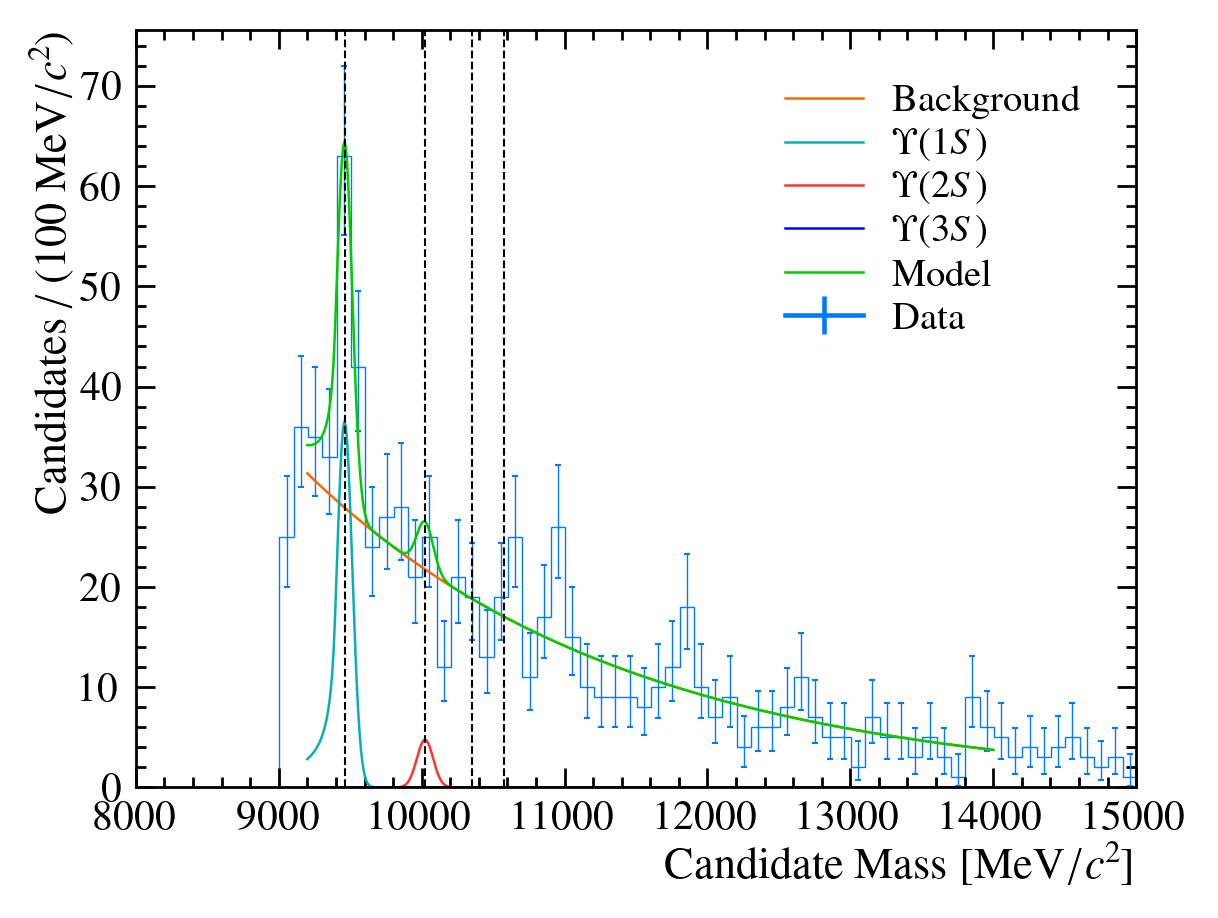

In [25]:
bin_width = 100
fig1, ax1 = histogram_fig(
    [p := HistogramPlot(df["J_psi_1S_M"], "Data", bins=bin_width, error=True, linewidth=1)],
    False,
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Candidate Mass",
    xlim=[8000, 15_000],
    # ylim=[0,50]
)

x = np.linspace(*bounds, 500)
ax1.plot(x, background.ext_pdf(x)*bin_width, label="Background", linewidth=1.8)
ax1.plot(x, signal_1S.ext_pdf(x)*bin_width, label=r"$\Upsilon(1S)$", linewidth=1.8)
ax1.plot(x, signal_2S.ext_pdf(x)*bin_width, label=r"$\Upsilon(2S)$", linewidth=1.8)
ax1.plot(x, signal_3S.ext_pdf(x)*bin_width, label=r"$\Upsilon(3S)$", linewidth=1.8)
ax1.plot(x, model.ext_pdf(x)*bin_width, label="Model", linewidth=1.8)
ax1.legend()

add_upsilon(ax1, range(1,5))